In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

- acceleration: g
- angular velocity: rad/s
- x axis: vertical, positive up
- y axis: medio-lateral, positive right
- z axis: antero-frontal, positive backward

### Common functions

In [2]:
def check_axes(df, subject_id=1, session_id=1, task_id=0):
    subset = df[
        (df['subjectID'] == subject_id) & 
        (df['sessionID'] == session_id) & 
        (df['taskID'] == task_id)
    ].copy()
    
    print(f"X orig: {subset['acc_x'].mean():+.3f} g")
    print(f"Y orig: {subset['acc_y'].mean():+.3f} g")
    print(f"Z orig: {subset['acc_z'].mean():+.3f} g")
    print(f"Var X: {subset['acc_x'].var():.5f}")
    print(f"Var Y: {subset['acc_y'].var():.5f}")
    print(f"Var Z: {subset['acc_z'].var():.5f}")

In [3]:
sensor_cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
group_cols = ["subjectID", "sessionID", "taskID"]

## FoG-STAR

In [4]:
fog_star_sensor = pd.read_csv("data/FoG-STAR/sensor_data.csv")
fog_star_sensor= fog_star_sensor[fog_star_sensor.activity>0]
fog_star_sensor.columns

Index(['timestamp', 'ankleL_acc_x', 'ankleL_acc_y', 'ankleL_acc_z',
       'ankleL_gyro_x', 'ankleL_gyro_y', 'ankleL_gyro_z', 'ankleR_acc_x',
       'ankleR_acc_y', 'ankleR_acc_z', 'ankleR_gyro_x', 'ankleR_gyro_y',
       'ankleR_gyro_z', 'back_acc_x', 'back_acc_y', 'back_acc_z',
       'back_gyro_x', 'back_gyro_y', 'back_gyro_z', 'wrist_acc_x',
       'wrist_acc_y', 'wrist_acc_z', 'wrist_gyro_x', 'wrist_gyro_y',
       'wrist_gyro_z', 'activity', 'fog', 'fog_severity', 'subjectID',
       'sessionID', 'taskID'],
      dtype='str')

In [5]:
#keep only the columns that are needed for the analysis and rename them for better understanding
fog_star_sensor = fog_star_sensor[["timestamp", "back_acc_x", "back_acc_y", "back_acc_z", "back_gyro_x", "back_gyro_y", "back_gyro_z","subjectID", "sessionID", "taskID", "activity", "fog"]]
fog_star_sensor.columns = ["timestamp", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z" ,"subjectID", "sessionID", "taskID", "activity", "fog"]

In [6]:
# task 2: Stand 1min, task 3: Walk 1min, task 4: Sit-to-stand
fog_star_sensor = fog_star_sensor[fog_star_sensor.taskID.isin([1, 2, 3])].copy()

fog_star_sensor['newTaskID'] = np.nan
fog_star_sensor['isTurn'] = 0

# - Task 2 (Stand 1min) -> Task 0
fog_star_sensor.loc[fog_star_sensor['taskID'] == 2, 'newTaskID'] = 0

# - Task 1 (Sit-to-stand) -> Task 10 to verify axes
mask_turns = (fog_star_sensor['taskID'] == 1) & (fog_star_sensor['activity']==4)
fog_star_sensor.loc[mask_turns, 'newTaskID'] = 10

# - Task 3 + Activity 6/7 (turns) -> Task 2 and add a column 0/1 if turn or walk
mask = (fog_star_sensor['taskID'] == 3) & (fog_star_sensor['fog'] == 0)
mask_turns = (fog_star_sensor['taskID'] == 3) & (fog_star_sensor['activity'].isin([6, 7]))
fog_star_sensor.loc[mask, 'newTaskID'] = 2
fog_star_sensor.loc[mask_turns, 'isTurn'] = 1

fog_star_sensor = fog_star_sensor.dropna(subset=['newTaskID']).copy()
fog_star_sensor['taskID'] = fog_star_sensor['newTaskID'].astype(int)
fog_star_sensor.drop(columns=['activity', 'fog', 'newTaskID'], inplace=True, errors='ignore')

print(fog_star_sensor['taskID'].value_counts())
fog_star_sensor.describe()

taskID
2     28666
0     10007
10     5262
Name: count, dtype: int64


,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,subjectID,sessionID,taskID,isTurn
count,43935.000000,40676.000000,40676.000000,40676.000000,40676.000000,40676.000000,40676.000000,43935.000000,43935.000000,43935.000000,43935.000000
mean,2921.125468,-0.954158,-0.061546,-0.143936,0.694734,0.042459,-0.167601,11.529191,1.063298,2.502606,0.179811
std,1552.425187,0.109807,0.159014,0.218506,25.606894,13.617246,8.237791,6.644400,0.243501,2.885098,0.384034
min,8.100000,-2.049729,-1.139950,-1.535227,-175.990473,-346.755248,-88.802204,1.000000,1.000000,0.000000,0.000000
25%,1591.391667,-1.004282,-0.153762,-0.322027,-5.003544,-3.696907,-2.389742,5.000000,1.000000,2.000000,0.000000
50%,3161.816667,-0.952601,-0.053745,-0.128066,-0.079818,0.104055,-0.500754,11.000000,1.000000,2.000000,0.000000
75%,4119.441667,-0.898079,0.042994,0.008079,6.790348,4.475743,2.391529,17.000000,1.000000,2.000000,0.000000
max,5281.950000,0.004142,0.905428,0.629047,191.407228,237.080367,83.405504,22.000000,2.000000,10.000000,1.000000


In [7]:
# remove group task+subject were all record for acc e gyro are nan
fog_star_sensor = fog_star_sensor.groupby(group_cols).filter(lambda x: not x[sensor_cols].isna().all().all())

In [8]:
# from deg/s to rad/s
fog_star_sensor["gyro_x"] = np.deg2rad(fog_star_sensor["gyro_x"])
fog_star_sensor["gyro_y"] = np.deg2rad(fog_star_sensor["gyro_y"])
fog_star_sensor["gyro_z"] = np.deg2rad(fog_star_sensor["gyro_z"])

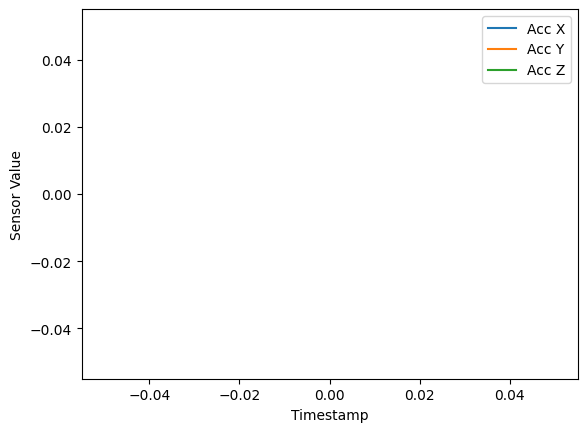

In [9]:
# plot the sensor data for one subject and session
subject_id = 17
session_id = 1
task_id = 2
subject_data = fog_star_sensor[(fog_star_sensor.subjectID == subject_id) & (fog_star_sensor.sessionID == session_id) & (fog_star_sensor.taskID == task_id) ]
#subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [10]:
check_axes(fog_star_sensor, subject_id=1, session_id=1, task_id=10)

X orig: -0.986 g
Y orig: -0.071 g
Z orig: -0.100 g
Var X: 0.00365
Var Y: 0.00293
Var Z: 0.04448


In [11]:
fog_star_sensor["acc_z"] = -fog_star_sensor["acc_z"]
fog_star_sensor["gyro_z"] = -fog_star_sensor["gyro_z"]

In [12]:
# remove tug task from the dataset
fog_star_sensor = fog_star_sensor[fog_star_sensor.taskID != 10].copy()

In [13]:
fog_star_clinical = pd.read_csv("data/FoG-STAR/clinical_data.csv")
fog_star_clinical.head()

,subjectID,age,gender,disease_duration,h_y,updrs_iii,fog_q,moca,fes-i,pdq8
0,1,65,M,15.0,4.0,47,19,17.0,29.0,22
1,2,72,F,10.0,4.0,61,17,17.0,27.0,29
2,3,83,F,6.0,4.0,57,18,15.0,25.0,12
3,4,85,M,3.0,2.0,40,8,22.0,11.0,3
4,5,62,M,11.0,2.0,21,15,26.0,15.0,13


### OMNIA-PARK

In [14]:
folder_path = "data/OMNIA-PARK/pd"

all_data = []

for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df = df.rename(columns={"Hips_timestamp": "Timestamp"})
        
        df = df[["subjectID", "Timestamp", "Hips_accX", "Hips_accY", "Hips_accZ", "Hips_gyroX", "Hips_gyroY", "Hips_gyroZ", "taskID"]].copy()
        df.columns = ["subjectID", "timestamp", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z", "taskID"]

        df = df[df.taskID.isin([7, 8, 2,4])]
        task_mapping = {7: 0, 8: 1, 2: 2, 4: 10}
        df.taskID = df.taskID.map(task_mapping)
        df["sessionID"] = 1
        
        all_data.append(df)

omnia_park_sensor = pd.concat(all_data, ignore_index=True)

In [15]:
# from deg/s to rad/s
omnia_park_sensor["gyro_x"] = np.deg2rad(omnia_park_sensor["gyro_x"])
omnia_park_sensor["gyro_y"] = np.deg2rad(omnia_park_sensor["gyro_y"])
omnia_park_sensor["gyro_z"] = np.deg2rad(omnia_park_sensor["gyro_z"])

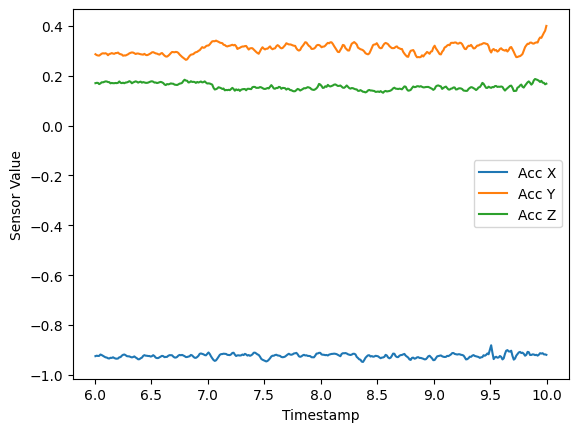

In [16]:
# plot the sensor data for one subject and session
subject_id = 19
session_id = 1
task_id = 2
subject_data = omnia_park_sensor[(omnia_park_sensor.subjectID == subject_id) & (omnia_park_sensor.sessionID == session_id) & (omnia_park_sensor.taskID == task_id) & (6 < omnia_park_sensor.timestamp) & (omnia_park_sensor.timestamp < 10)]
#subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [17]:
check_axes(omnia_park_sensor, subject_id=1, session_id=1, task_id=2)

X orig: -0.974 g
Y orig: -0.105 g
Z orig: +0.203 g
Var X: 0.01767
Var Y: 0.01078
Var Z: 0.01577


In [18]:
omnia_park_sensor = omnia_park_sensor[omnia_park_sensor.taskID != 10].copy()

In [19]:
# remove sub19 since incorrrect correspondence of tasks
omnia_park_sensor = omnia_park_sensor[omnia_park_sensor.subjectID != 19].copy()

In [20]:
omnia_park_clinical = pd.read_excel("data/OMNIA-PARK/clinical_info.xlsx")
omnia_park_clinical = omnia_park_clinical.rename(columns={"mds_updrs_3": "updrs_iii"})
omnia_park_clinical.head()

,subjectID,age,gender,disease_duration,h_y,updrs_iii,berg,postural_stability,posture,arising_chair
0,1,73,M,6,2.5,22,51,1,2,0
1,2,76,M,11,3.0,35,50,0,2,1
2,3,62,F,4,2.5,20,49,1,2,0
3,4,77,M,10,3.0,54,50,3,2,0
4,5,71,M,21,3.0,28,50,0,2,0


## PD-PHONE

In [21]:
folder_path = "data/PD-PHONE/pd"

all_data = []

for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        subject_id = file.split('.')[0].split('_')[1].replace('pd', '')  
        
        df = pd.read_csv(file_path)
        
        df = df.iloc[:, [0, 1, 2, 3, 4, 5, -1]].copy()
        df.columns = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z", "taskID"]
        
        df = df[df.taskID == 3].copy()
        
        df["taskID"] = 0
        
        df["subjectID"] = int(subject_id)
        df["sessionID"] = 1
        
        df["timestamp"] = np.arange(len(df)) / 200.0
        all_data.append(df)

pd_phone_sensor = pd.concat(all_data, ignore_index=True)
pd_phone_sensor.columns

Index(['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'taskID',
       'subjectID', 'sessionID', 'timestamp'],
      dtype='str')

In [22]:
g = 9.80665
pd_phone_sensor["acc_x"] = pd_phone_sensor["acc_x"] / g
pd_phone_sensor["acc_y"] = pd_phone_sensor["acc_y"] / g
pd_phone_sensor["acc_z"] = pd_phone_sensor["acc_z"] / g
pd_phone_sensor["isTurn"] = 0

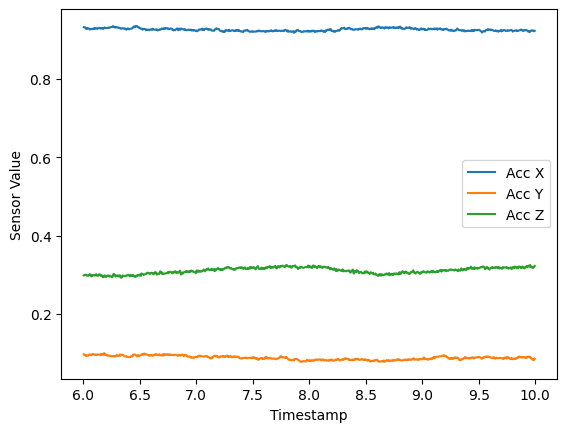

In [23]:
# plot the sensor data for one subject and session
subject_id = 2
session_id = 1
task_id = 0
subject_data = pd_phone_sensor[(pd_phone_sensor.subjectID == subject_id) & (pd_phone_sensor.sessionID == session_id) & (pd_phone_sensor.taskID == task_id) & (6 < pd_phone_sensor.timestamp) & (pd_phone_sensor.timestamp < 10)]
#subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [24]:
check_axes(pd_phone_sensor, subject_id=1, session_id=1, task_id=0)

X orig: +0.884 g
Y orig: +0.075 g
Z orig: +0.415 g
Var X: 0.00005
Var Y: 0.00005
Var Z: 0.00012


In [25]:
# exchange axes
pd_phone_sensor['acc_x'] = -pd_phone_sensor['acc_x']
pd_phone_sensor['gyro_x'] = -pd_phone_sensor['gyro_x']

In [26]:
pd_phone_clinical = pd.read_excel("data/PD-PHONE/clinical_info.xlsx")
pd_phone_clinical.head()

,subjectID,age,gender,disease_duration,h_y,updrs_iii,postural_stability,posture,dyskinesia,other_info
0,1,55.0,M,4.0,NaN,NaN,1.0,1.0,no,prima visita
1,2,84.0,M,3.0,NaN,NaN,NaN,NaN,no,"Encefalomielite, PT negativo ma molto instabile"
2,3,79.0,M,20.0,3.0,35.0,2.0,2.0,no,DBS
3,4,76.0,M,13.0,NaN,25.0,1.0,1.0,no,NaN
4,5,75.0,M,13.0,NaN,NaN,0.0,2.0,no,NaN


### WearPD

In [27]:
folder_path = "data/WearPD/pd"
all_data = []

col_keep = [
    'Time', 'GeneralEvent', 'ClinicalEvent',
    'LowerBack_Acc_X', 'LowerBack_Acc_Y', 'LowerBack_Acc_Z',
    'LowerBack_Gyr_X', 'LowerBack_Gyr_Y', 'LowerBack_Gyr_Z'
]

col_map = {
    'Time': 'timestamp',
    'LowerBack_Acc_X': 'acc_x', 'LowerBack_Acc_Y': 'acc_y', 'LowerBack_Acc_Z': 'acc_z',
    'LowerBack_Gyr_X': 'gyro_x', 'LowerBack_Gyr_Y': 'gyro_y', 'LowerBack_Gyr_Z': 'gyro_z'
}

for file in os.listdir(folder_path):
    if file.endswith('balance.csv') or file.endswith('selfpace_matturn.csv') or file.endswith('tug.csv'):
        file_path = os.path.join(folder_path, file)
        
        subject_id = file.split('_')[0]
        try:
            df = pd.read_csv(file_path, usecols=col_keep)
        except ValueError:
            print(f"Missing LowerBack sensor in: {file}. File skipped.")
            continue
        
    
        df_parts = [] 
        
        if 'balance' in file:
            df0 = df[df['GeneralEvent'].str.contains('EO_FeetShoWidth', na=False)].copy()
            df0['taskID'] = 0
            df0["isTurn"] = 0
            df_parts.append(df0)
                
            # Task 1: closed eyes, feet apart
            df1 = df[df['GeneralEvent'].str.contains('EC_FeetShoWidth', na=False)].copy()
            df1['taskID'] = 1
            df1["isTurn"] = 0
            df_parts.append(df1)
                
        elif 'selfpace_mat' in file:
            df2 = df.copy()
            df2['taskID'] = 2
            df2 = df2.sort_values('Time')
            
            df2['isTurn'] = 0
            
            if 'GeneralEvent' in df2.columns:
                mask_turns = df2['GeneralEvent'].str.contains('Turn', na=False)
                df2.loc[mask_turns, 'isTurn'] = 1
                
            df_parts.append(df2)

        elif "tug" in file:
            # Task 10: TUG
            df2 = df.copy()
            df2["isTurn"] = 0
            df2['taskID'] = 10
            df_parts.append(df2)
        
        if len(df_parts) > 0:
            df_file_completo = pd.concat(df_parts, ignore_index=True)
            df_file_completo = df_file_completo.rename(columns=col_map)
            df_file_completo["subjectID"] = subject_id
            df_file_completo["sessionID"] = 1
            df_file_completo.drop(columns=['GeneralEvent', 'ClinicalEvent'], inplace=True)
            df_file_completo["timestamp"] = df_file_completo["timestamp"].apply(lambda x: float(x.split(" ")[0]))
            
            all_data.append(df_file_completo)

wearpd_sensor = pd.concat(all_data, ignore_index=True)

Missing LowerBack sensor in: nls194_balance.csv. File skipped.
Missing LowerBack sensor in: nls194_selfpace_matturn.csv. File skipped.
Missing LowerBack sensor in: nls194_tug.csv. File skipped.


In [28]:
wearpd_sensor["acc_x"] = wearpd_sensor["acc_x"] / g
wearpd_sensor["acc_y"] = wearpd_sensor["acc_y"] / g
wearpd_sensor["acc_z"] = wearpd_sensor["acc_z"] / g

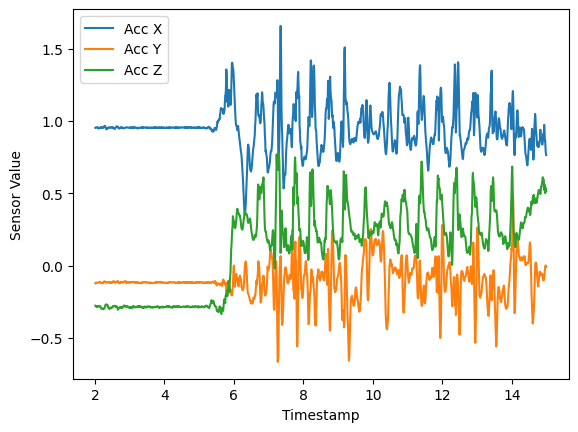

In [29]:
# plot the sensor data for one subject and session
subject_id = "nls022"
session_id = 1
task_id = 10
subject_data = wearpd_sensor[(wearpd_sensor.subjectID == subject_id) & (wearpd_sensor.sessionID == session_id) & (wearpd_sensor.taskID == task_id) & (2 < wearpd_sensor.timestamp) & (wearpd_sensor.timestamp < 15)]
#subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [30]:
check_axes(wearpd_sensor, subject_id="nls002", session_id=1, task_id=10)

X orig: +0.880 g
Y orig: -0.055 g
Z orig: -0.338 g
Var X: 0.04459
Var Y: 0.01406
Var Z: 0.10993


In [31]:
wearpd_sensor['acc_x'] = -wearpd_sensor['acc_x']
wearpd_sensor['gyro_x'] = -wearpd_sensor['gyro_x']

In [32]:
wearpd_sensor = wearpd_sensor[wearpd_sensor.taskID != 10].copy()

In [33]:
# remove group task+subject were all record for acc e gyro are nan
wearpd_sensor = wearpd_sensor.groupby(group_cols).filter(lambda x: not x[sensor_cols].isna().all().all())

In [34]:
wearpd_clinical = pd.read_csv("data/WearPD/PD - Demographic+Clinical - datasetV1.csv",header=[0, 1])
wearpd_clinical.columns

cols = []
for level1, level2 in wearpd_clinical.columns:
    l1 = str(level1).strip()
    l2 = str(level2).strip()
    if "Unnamed" in l1 or l1 == "-":
        cols.append(l2)
    else:
        cols.append(f"{l1}_{l2}")

wearpd_clinical.columns = cols

df_pd = wearpd_clinical.dropna(subset=['Subject ID']).copy()
df_pd['Subject ID'] = df_pd['Subject ID'].apply(lambda x: str(x).lower())

updrs3_cols = [col for col in df_pd.columns if 'MDSUPDRS_3' in col]
for col in updrs3_cols:
    df_pd[col] = pd.to_numeric(df_pd[col], errors='coerce')
df_pd['updrs_iii'] = df_pd[updrs3_cols].sum(axis=1, skipna=True)

cols_to_keep = {
    'Subject ID': 'subjectID',
    'Age (years)': 'age',
    'Sex': 'gender',                    
    'Years since PD diagnosis': 'disease_duration',
    'Modified Hoehn & Yahr Score': 'h_y',
    'updrs_iii': 'updrs_iii',        
    'POSTURAL STABILITY_MDSUPDRS_3-12': 'postural_stability'
}

wearpd_clinical = df_pd[list(cols_to_keep.keys())].rename(columns=cols_to_keep)
mapping = { "Male" : "M", "Female" : "F" }
wearpd_clinical['gender'] = wearpd_clinical['gender'].map(mapping)
wearpd_clinical.head()


,subjectID,age,gender,disease_duration,h_y,updrs_iii,postural_stability
0,nls139,67,M,2.26,2,33.0,0.0
1,nls140,75,M,10.29,3,40.0,2.0
2,nls056,64,F,3.5,2,32.0,3.0
3,nls124,59,M,26.42,3,41.0,3.0
4,nls035,55,F,7.38,1,20.0,0.0


## Kiel Dataset


In [35]:
folder_path = "data/kiel/control"
output_path = "data/cleaned_data/kiel_sensor.csv"

col_map = {
    'Time': 'timestamp',
    'LowerBack_Acc_X': 'acc_x', 'LowerBack_Acc_Y': 'acc_y', 'LowerBack_Acc_Z': 'acc_z',
    'LowerBack_Gyr_X': 'gyro_x', 'LowerBack_Gyr_Y': 'gyro_y', 'LowerBack_Gyr_Z': 'gyro_z'
}

# =========================================================
# LOADER CORRETTO PER FILE KIEL
# =========================================================
def load_kiel_mat(file_path):
    mat : dict = loadmat(file_path)
    data = mat['data']

    acc = data['acc'].item()    
    gyro = data['gyro'].item()
    fs = float(data['fs'][0].item())
    locations = data['imu_location'].item()
    sensor_idx = np.where(locations == 'pelvis')[0][0]

    acc = acc[:, :, sensor_idx]   
    gyro = gyro[:, :, sensor_idx]

    T = acc.shape[0]
    time = np.arange(T) / fs

    df = pd.DataFrame({
        'Time': time,
        'acc_x': acc[:, 0],
        'acc_y': acc[:, 1],
        'acc_z': acc[:, 2],
        'gyro_x': gyro[:, 0],
        'gyro_y': gyro[:, 1],
        'gyro_z': gyro[:, 2],
    })

    return df


# =========================================================
# LOOP DI PROCESSING
# =========================================================
all_data = []

if not os.path.exists(folder_path):
    print(f"Errore: {folder_path} non trovato.")
else:
    for dir_name in os.listdir(folder_path):
        imu_folder = os.path.join(folder_path, dir_name, "imu")
        if not os.path.exists(imu_folder):
            continue

        try:
            subject_id = int(dir_name.replace("pp", ""))
        except:
            continue

        for file in os.listdir(imu_folder):
            valid_files = ['imu_tug.mat', 'imu_walk_turn.mat', 'imu_balance_sbs.mat']
            if file not in valid_files:
                continue

            file_path = os.path.join(imu_folder, file)

            try:
                df = load_kiel_mat(file_path)
                df_parts = []

                if 'balance_sbs' in file:
                    df0 = df.copy()
                    df0['taskID'] = 0
                    df_parts.append(df0)

                elif 'walk_turn' in file:
                    df2 = df.copy()
                    df2['taskID'] = 2
                    df_parts.append(df2)

                elif 'tug' in file:
                    df10 = df.copy()
                    df10['taskID'] = 10
                    df_parts.append(df10)

                if df_parts:
                    df_res = pd.concat(df_parts, ignore_index=True)
                    df_res = df_res.rename(columns=col_map)

                    df_res["subjectID"] = subject_id
                    df_res["sessionID"] = 1

                    cols_fin = [
                        'subjectID', 'sessionID', 'taskID', 
                        'timestamp',
                        'acc_x', 'acc_y', 'acc_z',
                        'gyro_x', 'gyro_y', 'gyro_z'
                    ]

                    df_res = df_res[[c for c in cols_fin if c in df_res.columns]]
                    all_data.append(df_res)

            except Exception as e:
                print(f"Errore caricamento {file}: {e}")
kiel_sensor = pd.concat(all_data, ignore_index=True)


C:\Users\chiar\AppData\Local\Temp\ipykernel_18024\1362669485.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(data['fs'][0].item())
C:\Users\chiar\AppData\Local\Temp\ipykernel_18024\1362669485.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(data['fs'][0].item())
C:\Users\chiar\AppData\Local\Temp\ipykernel_18024\1362669485.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(data['fs'][0].item())
C:\Users\chiar\AppData\Local

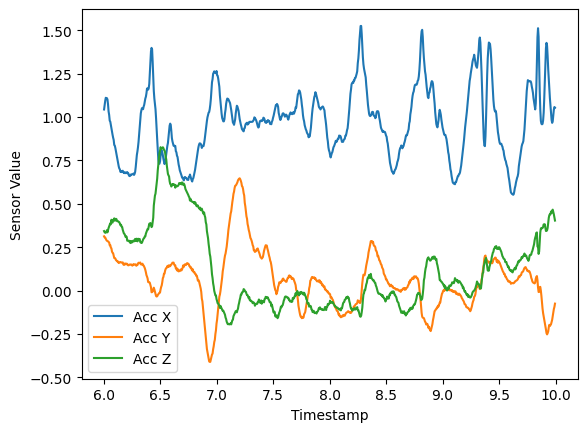

In [36]:
# plot the sensor data for one subject and session
subject_id = 10
session_id = 1
task_id = 2
subject_data = kiel_sensor[(kiel_sensor.subjectID == subject_id) & (kiel_sensor.sessionID == session_id) & (kiel_sensor.taskID == task_id) & (6 < kiel_sensor.timestamp) & (kiel_sensor.timestamp < 10)]
#subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [37]:
# convert to rad/s
kiel_sensor["gyro_x"] = np.deg2rad(kiel_sensor["gyro_x"])
kiel_sensor["gyro_y"] = np.deg2rad(kiel_sensor["gyro_y"])
kiel_sensor["gyro_z"] = np.deg2rad(kiel_sensor["gyro_z"])

In [38]:
kiel_sensor['acc_x'] = -kiel_sensor['acc_x']
kiel_sensor['gyro_x'] = -kiel_sensor['gyro_x']
# exchange z axis and y axis
kiel_sensor['acc_z'], kiel_sensor['acc_y'] = kiel_sensor['acc_y'], kiel_sensor['acc_z']
kiel_sensor['gyro_z'], kiel_sensor['gyro_y'] = kiel_sensor['gyro_y'], kiel_sensor['gyro_z']
kiel_sensor = kiel_sensor[kiel_sensor.taskID != 10].copy()

In [39]:
# clinical data
kiel_clinical = pd.read_excel("data/kiel/demographics_scores_extern.xlsx")
kiel_clinical.columns
kiel_clinical = kiel_clinical[["id", "gender", "age", "hoehn_u_yahr", "updrs_3_total", "updrs_3_12_postural_stab"]]
kiel_clinical = kiel_clinical.rename(columns={
    "id": "subjectID",
    "hoehn_u_yahr": "h_y",
    "updrs_3_total": "updrs_iii",
    "updrs_3_12_postural_stab": "postural_stability"
})
map_gender = {0: "M", 1: "F"}
kiel_clinical['gender'] = kiel_clinical['gender'].map(map_gender)
kiel_clinical.head()

,subjectID,gender,age,h_y,updrs_iii,postural_stability
0,1,F,25,NaN,0,0
1,2,M,34,NaN,0,0
2,3,M,32,NaN,2,0
3,6,M,37,NaN,8,0
4,10,F,70,NaN,8,0


### Ensure datasets consistency

In [40]:
# for each dataset check if all users have a corresponding clinical record
datasets = ["fog_star", "omnia_park", "pd_phone", "wearpd", "kiel"]

for dataset in datasets:
    print(f"Dataset: {dataset}")
    if dataset == "fog_star":
        sensor_df = fog_star_sensor
        clinical_df = fog_star_clinical
        subject_col = "subjectID"
    elif dataset == "omnia_park":
        sensor_df = omnia_park_sensor
        clinical_df = omnia_park_clinical
        subject_col = "subjectID"
    elif dataset == "pd_phone":
        sensor_df = pd_phone_sensor
        clinical_df = pd_phone_clinical
        subject_col = "subjectID"
    elif dataset == "wearpd":
        sensor_df = wearpd_sensor
        clinical_df = wearpd_clinical
        subject_col = "subjectID"
    elif dataset == "kiel":
        sensor_df = kiel_sensor
        clinical_df = kiel_clinical
        subject_col = "subjectID"
    
    sensor_subjects = set(sensor_df[subject_col].unique())
    clinical_subjects = set(clinical_df[subject_col].unique())
    
    missing_in_clinical = sensor_subjects - clinical_subjects
    missing_in_sensor = clinical_subjects - sensor_subjects
    
    if len(missing_in_clinical) > 0:
        print(f"  Subjects in sensor data but missing in clinical data: {missing_in_clinical}")
    else:
        print("  All subjects in sensor data have a corresponding clinical record.")
    
    if len(missing_in_sensor) > 0:
        print(f"  Subjects in clinical data but missing in sensor data: {missing_in_sensor}")
    else:
        print("  All subjects in clinical data have a corresponding sensor record.")


Dataset: fog_star
  All subjects in sensor data have a corresponding clinical record.
  Subjects in clinical data but missing in sensor data: {6, 7, 8, 12, 17, 21}
Dataset: omnia_park
  All subjects in sensor data have a corresponding clinical record.
  Subjects in clinical data but missing in sensor data: {19}
Dataset: pd_phone
  All subjects in sensor data have a corresponding clinical record.
  All subjects in clinical data have a corresponding sensor record.
Dataset: wearpd
  All subjects in sensor data have a corresponding clinical record.
  Subjects in clinical data but missing in sensor data: {'nls033', 'nls194'}
Dataset: kiel
  All subjects in sensor data have a corresponding clinical record.
  Subjects in clinical data but missing in sensor data: {36, 37, 31}


In [41]:
# check columns correspondence between datasets and create final csv files for each dataset with only the columns needed for the analysis and renamed for better understanding
# create folder cleaned_data with the following structure:
# nameDataset_sensor.csv: subjectID, sessionID, taskID, timestamp, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z
# nameDataset_clinical.csv: subjectID, age, gender, disease_duration, h_y, updrs_iii, postural_stability (Nan if not available)

output_folder = "data/cleaned_data"
os.makedirs(output_folder, exist_ok=True)

TARGET_SENSOR_COLS = [
    'subjectID', 'sessionID', 'taskID', 'timestamp', 'isTurn', 
    'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z'
]

TARGET_CLINICAL_COLS = [
    'subjectID', 'age', 'gender', 'disease_duration', 
    'h_y', 'updrs_iii', 'postural_stability'
]

def save_dataset(df_sensor, df_clinical, dataset_name):
    df_s = df_sensor.copy()
    
    for col in TARGET_SENSOR_COLS:
        if col not in df_s.columns:
            df_s[col] = np.nan
            
    df_s = df_s[TARGET_SENSOR_COLS]
    df_s.to_csv(os.path.join(output_folder, f"{dataset_name}_sensor.csv"), index=False)

    if df_clinical is not None:
        df_c = df_clinical.copy()
        
        for col in TARGET_CLINICAL_COLS:
            if col not in df_c.columns:
                df_c[col] = np.nan
                
        df_c = df_c[TARGET_CLINICAL_COLS]
        df_c.to_csv(os.path.join(output_folder, f"{dataset_name}_clinical.csv"), index=False)


In [42]:
def check_imu_standard(group, sf):
    """
    Controlla se i dati rispettano lo standard:
    X=UP (+1g), Y=RIGHT (0g), Z=BACKWARD (0g).
    Ritorna un dizionario con i risultati dei test.
    """
    # 1. Analisi della gravitÃ  (primi 0.5s di stance)
    ref_data = group[['acc_x', 'acc_y', 'acc_z']].head(int(sf/2))
    mean_acc = ref_data.mean()
    total_norm = np.sqrt((mean_acc**2).sum())
    
    # 2. Analisi della dinamica (varianza durante il movimento)
    # Serve a capire se Antero-Posteriore e Medio-Laterale sono scambiati
    variances = group[['acc_y', 'acc_z']].var()
    
    report = {
        "is_unit_g": 0.9 <= total_norm <= 1.1,
        "is_x_vertical": mean_acc.abs().idxmax() == 'acc_x',
        "is_x_positive_up": mean_acc['acc_x'] < 0,
        "is_z_anteroposterior": variances.idxmax() == 'acc_z', # Z dovrebbe oscillare di piÃ¹
        "norm_value": round(total_norm, 3),
        "gravity_on_axis": mean_acc.idxmax()
    }
    
    # Stampa avvisi se qualcosa non va
    if not report["is_unit_g"]:
        print(f"âš ï¸ Errore UnitÃ : Norma = {report['norm_value']}g (Forse m/s^2 o non calibrato?)")
    if not report["is_x_vertical"]:
        print(f"âš ï¸ Errore Orientamento: GravitÃ  trovata su {report['gravity_on_axis']}")
    if report["is_x_vertical"] and not report["is_x_positive_up"]:
        print("âš ï¸ Errore Segno: L'asse X Ã¨ verticale ma punta verso il basso (DOWN).")
    if not report["is_z_anteroposterior"]:
        print("âš ï¸ Errore Assi: L'asse Y oscilla piÃ¹ di Z. Forse sono scambiati (Antero vs Lat).")
        
    return report

In [43]:
datasets_dict = {
    "fog_star": (fog_star_sensor, fog_star_clinical),
    "omnia_park": (omnia_park_sensor, omnia_park_clinical),
    "pd_phone": (pd_phone_sensor, pd_phone_clinical),
    "wearpd": (wearpd_sensor, wearpd_clinical),
    "kiel": (kiel_sensor, kiel_clinical)
}

for dataset_name, (df_sensor, df_clinical) in datasets_dict.items():
    print(f"\nProcessing dataset: {dataset_name}")
    
    if not df_sensor.empty:
        test_subject = df_sensor['subjectID'].iloc[0]
        test_session = df_sensor['sessionID'].iloc[0]
        test_task = df_sensor['taskID'].iloc[0]
        
        subject_data = df_sensor[(df_sensor['subjectID'] == test_subject) & (df_sensor['sessionID'] == test_session) & (df_sensor['taskID'] == test_task)]
        
        time_diff = subject_data['timestamp'].diff().mean()

        freq_hz = 1 / time_diff
        print(f"  Estimated frequency: {freq_hz:.2f} Hz")

        check_imu_standard(subject_data, freq_hz)
        
    save_dataset(df_sensor, df_clinical, dataset_name)


Processing dataset: fog_star
  Estimated frequency: 60.00 Hz

Processing dataset: omnia_park
  Estimated frequency: 90.00 Hz

Processing dataset: pd_phone
  Estimated frequency: 200.00 Hz

Processing dataset: wearpd
  Estimated frequency: 100.00 Hz

Processing dataset: kiel
  Estimated frequency: 200.00 Hz
âš ï¸ Errore Assi: L'asse Y oscilla piÃ¹ di Z. Forse sono scambiati (Antero vs Lat).


In [44]:
from extract_turn.extract_turn import extract_turns_from_dataset

path = f"data/cleaned_data/omnia_park_sensor.csv"

# Chiamiamo la funzione
df_processed = extract_turns_from_dataset(path, sf=90, tasks_to_process=[2])

# Se vuoi sovrascrivere il file o salvarlo in una nuova cartella
if df_processed is not None:
    output_path = f"data/cleaned_data/omnia_park_sensor.csv"
    df_processed.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

Loading cleaned_data/omnia_park_sensor.csv...
Extraction complete: 166125 rows flagged as turns out of 1067459.
Saved: cleaned_data/omnia_park_sensor.csv
